# EDA – Análise Exploratória de Elogio vs Queixa

Este notebook existe para **entender os dados e o comportamento do modelo**, não para treinar ou melhorar algoritmos.

**Objetivos principais:**
- Compreender a distribuição das classes
- Visualizar características dos textos
- Analisar erros reais do modelo
- Apoiar decisões estratégicas (não ajustes finos ainda)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


## Carregamento de bibliotecas

Aqui importamos apenas ferramentas de **análise e visualização**.
Nada de pipeline de produção. Este é um ambiente exploratório.

In [9]:
DATASET_PATH = "../data/processed/comentarios_processados_full.csv"

df = pd.read_csv(DATASET_PATH)

# ELOGIO_QUEIXA da coluna "elogio_ou_queixa" é ambíguo, então vamos transforma-lo em "QUEIXA"
df["elogio_ou_queixa"] = df["elogio_ou_queixa"].replace("ELOGIO_QUEIXA", "QUEIXA")

df.head()

,elogio_ou_queixa,grupo,motivo,comentario,fase
0,QUEIXA,ADMINISTRATIVO,QUALIDADE,"A quantidade absurda de contribuintes , e a pe...",p1
1,QUEIXA,RECEPÇAO,TEMPO DE ESPERA,Eu estive no Tereza de lizeut por conta de um ...,p1
2,QUEIXA,RECEPÇAO,TEMPO DE ESPERA,Não tive ajuda alguma de maqueiros ou porteiro...,p1
3,QUEIXA,RECEPÇAO,ACOLHIMENTO,"Boa Noite, não fiz cirurgia, foi internação po...",p1
4,QUEIXA,RECEPÇAO,TEMPO DE ESPERA,"Demorou muito, uma dificuldade pra internar, a...",p1


## Carregamento do dataset

Usamos o **dataset final processado**, o mesmo utilizado no treino.
Isso garante que estamos analisando exatamente o que o modelo viu.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30394 entries, 0 to 30393
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   elogio_ou_queixa  21115 non-null  object
 1   grupo             25025 non-null  object
 2   motivo            20959 non-null  object
 3   comentario        30394 non-null  object
 4   fase              30394 non-null  object
dtypes: object(5)
memory usage: 1.2+ MB


## Visão geral dos dados

Nesta etapa buscamos responder:
- Quantas linhas existem?
- Quais colunas estão disponíveis?
- Existem valores ausentes?

Nenhuma decisão é tomada aqui. Apenas observação.

In [11]:
df["elogio_ou_queixa"].value_counts()

elogio_ou_queixa
QUEIXA    20152
ELOGIO      963
Name: count, dtype: int64

## Distribuição das classes

Este gráfico mostra o **desbalanceamento do problema**.

Ele explica por que métricas como accuracy podem ser enganosas e por que o modelo tende a favorecer a classe majoritária.

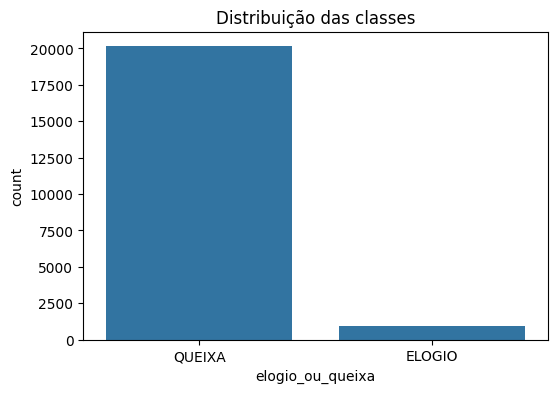

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="elogio_ou_queixa")
plt.title("Distribuição das classes")
plt.show()

## Tamanho dos comentários

Aqui analisamos o comprimento dos textos.

Objetivo:
- Ver se elogios e queixas têm tamanhos diferentes
- Avaliar impacto de textos muito curtos
- Apoiar decisões como `MIN_TEXTO_LEN`

In [14]:
df["len_comentario"] = df["comentario"].str.len()

## Carregamento do modelo treinado

Neste ponto **não estamos treinando nada**.

Apenas carregamos o modelo já salvo para observar como ele se comporta frente aos dados.

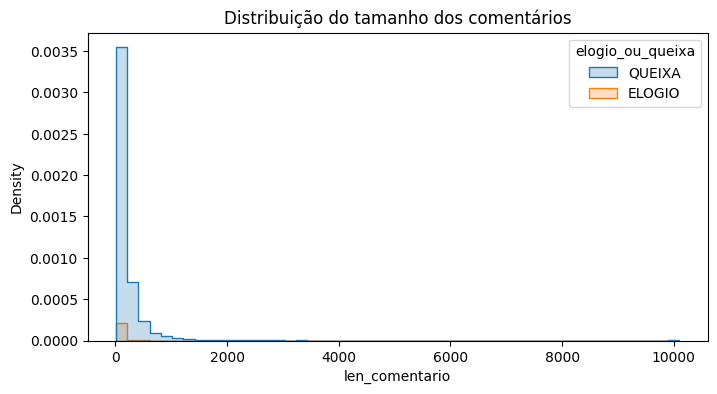

In [15]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x="len_comentario",
    hue="elogio_ou_queixa",
    bins=50,
    element="step",
    stat="density"
)
plt.title("Distribuição do tamanho dos comentários")
plt.show()

## Geração das previsões

Aqui criamos a visão do modelo:
- `y_true`: rótulo real
- `y_pred`: rótulo previsto

Isso nos permite comparar humano vs modelo.

In [16]:
import joblib

model_data = joblib.load("../models/elogio_queixa/elogio_queixa.pkl")
model = model_data["model"]
vectorizer = model_data["vectorizer"]

## Matriz de confusão

A matriz de confusão mostra **onde o modelo erra**.

Ela é mais intuitiva que métricas agregadas e revela padrões de confusão entre classes.

In [24]:
X = df["comentario"]
y_true = df["elogio_ou_queixa"]

X_vec = vectorizer.transform(X)
y_pred = model.predict(X_vec)


## Análise dos erros reais

Este é o ponto mais importante do notebook.

Aqui lemos exemplos concretos onde o modelo errou.
O objetivo não é julgar o modelo, mas entender:
- Ambiguidade do texto
- Possível erro de rótulo
- Limites naturais do problema

In [18]:
X = df["comentario"]
y_true = df["elogio_ou_queixa"]

X_vec = vectorizer.transform(X)
y_pred = model.predict(X_vec)


## Matriz de confusão (erros agregados)

Neste bloco analisamos os erros do modelo de forma **agregada**,
ou seja, olhando padrões gerais e não exemplos individuais.

Objetivo deste passo:
- Ver quais classes o modelo mais confunde
- Entender a direção predominante dos erros
- Identificar limites estruturais do problema

Aqui ainda não analisamos texto por texto.
A matriz mostra o **efeito estatístico** da ambiguidade,
de possíveis erros de rótulo e do desbalanceamento dos dados.


In [ ]:
# remove linhas com rótulo ausente
mask = y_true.notna()

y_true_clean = y_true[mask]
y_pred_clean = y_pred[mask]

# matriz de confusão sem mistura de tipos
cm = confusion_matrix(
    y_true_clean,
    y_pred_clean,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão")
plt.show()

## Leitura de erros reais (nível texto)

Neste bloco analisamos **exemplos concretos onde a previsão do modelo
é diferente do rótulo original**.

Objetivo deste passo:
- Ler erros como humano, não como estatística
- Identificar ambiguidade semântica nos textos
- Detectar possíveis erros ou ausência de rótulo
- Reconhecer comentários fora do escopo do problema

Este é o ponto onde o modelo deixa de ser número
e passa a ser interpretado no contexto real dos dados.

Observação:
Neste conjunto também aparecem comentários com rótulo ausente (NaN).
Eles não representam erro do modelo, mas dados fora do escopo de classificação.



In [30]:
df_erros = df[y_true != y_pred]
df_erros.sample(50)[["comentario", "elogio_ou_queixa"]]


,comentario,elogio_ou_queixa
27420,Satisfeito,NaN
3675,Não tivemos acompanhamento com nenhum desses m...,NaN
10569,"Não estou insatisfeita , só não utilizei o ser...",NaN
2269,não tive esse atendimento,NaN
18183,Não tive suporte desses profissionais,NaN
11280,Quase não tive atendimento só com fisioterapia,NaN
25880,Não tive nenhum profissional dessa área me ate...,NaN
11564,Não recebi atendimento de nenhum desses especi...,NaN
20118,A paciente elogia a equipe de enfermagem da UT...,ELOGIO
748,Desculpe. Me enganei. Não é nota 1 e sim nota 5,NaN
